# chi^2/n vs raw chi^2 (sum) training loss — replica-band comparison\n\n`CustomLoss` was changed from a raw sum `chi^2 = sum_i ((pred_i - y_i)/sigma_i)^2` to\na reduced chi^2 `chi^2/n = (1/n) * sum_i (...)^2` (matching Gepard's `torch.mean`\nconvention). This notebook checks whether that normalization changes the fitted CFFs\nor the replica uncertainty band, using a **seed-matched A/B pair**: `cff_model_replica_NN.json`\n(chi^2/n) and `cff_model_replica_origloss_NN.json` (raw chi^2 sum) were trained with\nidentical smear draw / train-val split / initial weights per replica index\n(`base_seed=42`, retries enabled), differing *only* in the loss normalization.\n\n**Result: all 10 replica pairs converged to bit-identical training trajectories** —\nsame early-stopping epoch, and `val_chi2_raw == 4 * val_chi2_per_n` exactly (n_val=4)\nfor every replica. This confirms Adam's update is (to floating-point precision)\ninvariant to a constant loss rescaling, so the loss normalization itself does not\nchange the trained weights — any earlier-observed difference in band width was\nordinary run-to-run variance between independently-seeded ensembles, not an effect\nof chi^2 vs chi^2/n.\n\n(A first attempt at this A/B pair, with retries *disabled* to force an exact seed\npairing, hit one replica that diverged to NaN at epoch 1 under chi^2/n only — traced\nto Adam's epsilon term not being exactly scale-invariant, `-lr*g/(|g|+eps)` becoming\n`-lr*g/(|g|+n*eps)` under an n-fold gradient rescale. Re-running with the *same* seed\nbut retries enabled, that replica converged cleanly instead — so the NaN was actually\nfloating-point run-to-run nondeterminism (likely thread-scheduling-dependent summation\norder in a multi-threaded BLAS/PARTONS computation) landing a numerically fragile\ntrajectory on the wrong side of a knife edge, not a deterministic consequence of the\nseed. Worth knowing if a future run hits an isolated NaN replica: retry, don't assume\nit's reproducible.)\n\n| File set | Loss used | Seed |\n|---|---|---|\n| `cff_model_replica_NN.json` | chi^2/n (current) | `base_seed=42` |\n| `cff_model_replica_origloss_NN.json` | raw chi^2 sum (original) | `base_seed=42` (same) |

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def cff_forward(X, model):
    """X: array [...,3] = (xB, t, Q2). Returns [...,n_outputs], columns = labels.
    Mirrors DVCSCFFNNTorch::forwardNN(): float32 + (x - xmin)/clamp(xmax - xmin, 1e-8),
    then CFF = xB**x_pow * NNet_output (raw, unscaled xB; x_pow defaults to 0)."""
    W1 = np.array(model['fc1']['weight'], dtype=np.float32)   # [hidden, in]
    b1 = np.array(model['fc1']['bias'],   dtype=np.float32)   # [hidden]
    W2 = np.array(model['fc2']['weight'], dtype=np.float32)   # [out, hidden]
    b2 = np.array(model['fc2']['bias'],   dtype=np.float32)   # [out]
    xmin = np.array(model['scaling']['x_min'], np.float32) if model['scaling']['x_min'] is not None else None
    xmax = np.array(model['scaling']['x_max'], np.float32) if model['scaling']['x_max'] is not None else None
    x_pow = model.get('x_pow', 0.0)

    X = np.asarray(X, dtype=np.float32)
    xB_raw = X[..., 0]
    if xmin is not None and xmax is not None:
        X = (X - xmin) / np.maximum(xmax - xmin, 1e-8).astype(np.float32)
    H = np.tanh(X @ W1.T + b1)
    out = H @ W2.T + b2
    return out * (xB_raw ** x_pow)[..., None]


def cff_scan(xB, t, Q2, model):
    """Broadcast scalar/array xB,t,Q2 -> [N,3], forward -> [N, n_outputs]."""
    xB, t, Q2 = np.broadcast_arrays(np.float32(xB), np.float32(t), np.float32(Q2))
    X = np.stack([xB.ravel(), t.ravel(), Q2.ravel()], axis=1)
    return cff_forward(X, model)

In [9]:
N_REPLICAS = 10

newloss_models = []
for i in range(N_REPLICAS):
    with open(f'../Partons_output/cff_model_replica_{i:02d}.json') as f:
        newloss_models.append(json.load(f))

origloss_models = []
for i in range(N_REPLICAS):
    with open(f'../Partons_output/cff_model_replica_origloss_{i:02d}.json') as f:
        origloss_models.append(json.load(f))

labels = newloss_models[0]['output_layer']

for i, m in enumerate(newloss_models + origloss_models):
    assert m['output_layer'] == labels, f'model {i}: output_layer mismatch'
    assert m['arch'] == newloss_models[0]['arch'], f'model {i}: arch mismatch'
    assert m.get('x_pow', 0.0) == newloss_models[0].get('x_pow', 0.0), f'model {i}: x_pow mismatch'

print(f'Loaded {len(newloss_models)} chi^2/n replicas + {len(origloss_models)} raw-chi^2 replicas')
print('CFFs output by the NN:', labels)

Loaded 10 chi^2/n replicas + 10 raw-chi^2 replicas
CFFs output by the NN: ['ImH']


## Best validation loss per replica (sanity check)

`best_val_chi2` is chi^2/n for the new-loss set and the raw sum for the orig-loss
set. With the seed-matched pairing, `raw == 4 * (chi^2/n)` exactly (n_val=4) for
every replica below — direct numeric confirmation that both runs found the same
minimum.

In [10]:
print(f"{'replica':>7}  {'chi2/n (new)':>14}  {'raw sum (orig)':>16}")
for i in range(N_REPLICAS):
    print(f"{i:>7}  {newloss_models[i].get('best_val_chi2', float('nan')):>14.5g}  "
          f"{origloss_models[i].get('best_val_chi2', float('nan')):>16.5g}")

replica    chi2/n (new)    raw sum (orig)
      0          5.0689            20.276
      1          1.6684            6.6736
      2          8.2106            32.842
      3          1.3168             5.267
      4         0.64785            2.5914
      5          2.0949            8.3797
      6          0.4357            1.7428
      7          1.2269            4.9074
      8          1.5815             6.326
      9          1.8326            7.3304


## CFFs vs $x_B$ (fixed $t=-0.2$ GeV$^2$, $Q^2=2$ GeV$^2$) — chi^2/n vs raw chi^2 bands

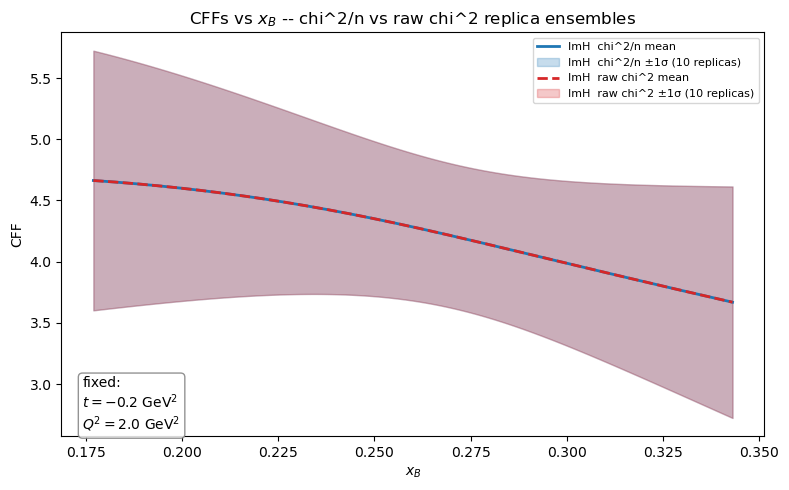

  k  label   mean sigma (chi2/n)    mean sigma (raw)    ratio
  0    ImH               0.76162             0.76162    1.000


In [11]:
xB = np.linspace(0.177, 0.343, 300)  # to match the fitted range
t_fix, Q2_fix = -0.2, 2.0

newloss_curves  = np.stack([cff_scan(xB, t_fix, Q2_fix, m) for m in newloss_models])   # [10, 300, n_out]
origloss_curves = np.stack([cff_scan(xB, t_fix, Q2_fix, m) for m in origloss_models])  # [10, 300, n_out]

newloss_mean, newloss_std   = newloss_curves.mean(axis=0),  newloss_curves.std(axis=0)
origloss_mean, origloss_std = origloss_curves.mean(axis=0), origloss_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    ax.plot(xB, newloss_mean[:, k], lw=2, color='C0', label=f'{name}  chi^2/n mean')
    ax.fill_between(xB, newloss_mean[:, k] - newloss_std[:, k], newloss_mean[:, k] + newloss_std[:, k],
                     color='C0', alpha=0.25, label=f'{name}  chi^2/n ±1σ ({N_REPLICAS} replicas)')
    ax.plot(xB, origloss_mean[:, k], lw=2, ls='--', color='C3', label=f'{name}  raw chi^2 mean')
    ax.fill_between(xB, origloss_mean[:, k] - origloss_std[:, k], origloss_mean[:, k] + origloss_std[:, k],
                     color='C3', alpha=0.25, label=f'{name}  raw chi^2 ±1σ ({N_REPLICAS} replicas)')
ax.set_xlabel(r'$x_B$')
ax.set_ylabel('CFF')
ax.set_title(r'CFFs vs $x_B$ -- chi^2/n vs raw chi^2 replica ensembles')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Plots/compare_chi2n_vs_rawchi2_vs_xB.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'k':>3} {'label':>6}  {'mean sigma (chi2/n)':>20}  {'mean sigma (raw)':>18}  {'ratio':>7}")
for k, name in enumerate(labels):
    s_new, s_orig = newloss_std[:, k].mean(), origloss_std[:, k].mean()
    print(f"{k:>3} {name:>6}  {s_new:>20.5g}  {s_orig:>18.5g}  {s_new / s_orig:>7.3f}")

## CFFs vs $-t$ (fixed $x_B=0.2$, $Q^2=2.2$ GeV$^2$) — chi^2/n vs raw chi^2 bands

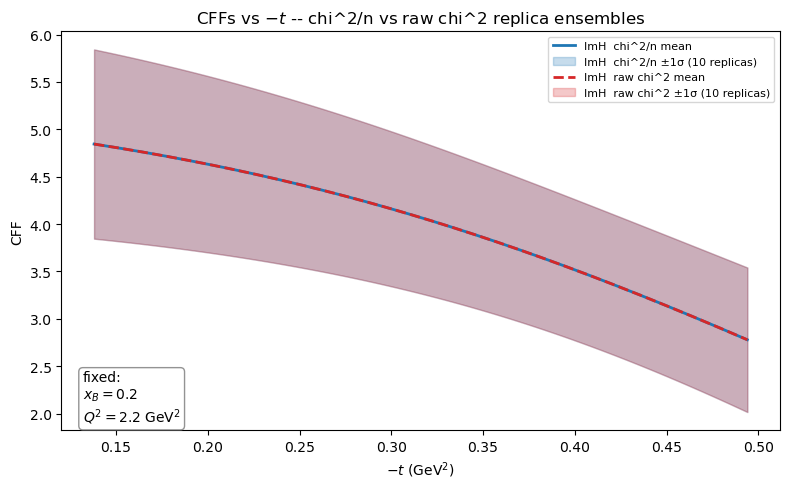

  k  label   mean sigma (chi2/n)    mean sigma (raw)    ratio
  0    ImH               0.82795             0.82795    1.000


In [12]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|, to match the fitted range
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

newloss_curves  = np.stack([cff_scan(xB_fix, t, Q2_fix, m) for m in newloss_models])
origloss_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m) for m in origloss_models])

newloss_mean, newloss_std   = newloss_curves.mean(axis=0),  newloss_curves.std(axis=0)
origloss_mean, origloss_std = origloss_curves.mean(axis=0), origloss_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    ax.plot(mt, newloss_mean[:, k], lw=2, color='C0', label=f'{name}  chi^2/n mean')
    ax.fill_between(mt, newloss_mean[:, k] - newloss_std[:, k], newloss_mean[:, k] + newloss_std[:, k],
                     color='C0', alpha=0.25, label=f'{name}  chi^2/n ±1σ ({N_REPLICAS} replicas)')
    ax.plot(mt, origloss_mean[:, k], lw=2, ls='--', color='C3', label=f'{name}  raw chi^2 mean')
    ax.fill_between(mt, origloss_mean[:, k] - origloss_std[:, k], origloss_mean[:, k] + origloss_std[:, k],
                     color='C3', alpha=0.25, label=f'{name}  raw chi^2 ±1σ ({N_REPLICAS} replicas)')
ax.set_xlabel(r'$-t$ (GeV$^2$)')
ax.set_ylabel('CFF')
ax.set_title(r'CFFs vs $-t$ -- chi^2/n vs raw chi^2 replica ensembles')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Plots/compare_chi2n_vs_rawchi2_vs_mt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'k':>3} {'label':>6}  {'mean sigma (chi2/n)':>20}  {'mean sigma (raw)':>18}  {'ratio':>7}")
for k, name in enumerate(labels):
    s_new, s_orig = newloss_std[:, k].mean(), origloss_std[:, k].mean()
    print(f"{k:>3} {name:>6}  {s_new:>20.5g}  {s_orig:>18.5g}  {s_new / s_orig:>7.3f}")